## Exploratory Data Analysis

In [6]:
import pandas as pd
df = pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Basic Statistics

In [7]:
# Dataset dimensions and column types
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print("\nColumn dtypes:")
print(df.dtypes)
print("\n" + "=" * 60)
df.info()

Rows: 541,909  |  Columns: 8

Column dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
# Numeric summary
display(df.describe())

# Categorical / ID columns (unique counts)
cat_cols = ["InvoiceNo", "StockCode", "Description", "Country"]
summary = pd.DataFrame({
    "unique_values": [df[c].nunique() for c in cat_cols],
    "most_frequent": [df[c].mode().iloc[0] if df[c].notna().any() else None for c in cat_cols],
    "freq_of_top": [df[c].value_counts().iloc[0] for c in cat_cols],
}, index=cat_cols)
print("Categorical overview:")
display(summary)

# Missing values
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
})
print("\nMissing values:")
display(missing[missing["missing_count"] > 0])

# Time span
print(f"\nInvoice date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Span: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

# Key business counts
print(f"\nUnique invoices: {df['InvoiceNo'].nunique():,}")
print(f"Unique products (StockCode): {df['StockCode'].nunique():,}")
print(f"Unique customers (non-null CustomerID): {df['CustomerID'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


Categorical overview:


,unique_values,most_frequent,freq_of_top
InvoiceNo,25900,573585,1114
StockCode,4070,85123A,2313
Description,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
Country,38,United Kingdom,495478



Missing values:


,missing_count,missing_pct
Description,1454,0.27
CustomerID,135080,24.93



Invoice date range: 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Span: 373 days

Unique invoices: 25,900
Unique products (StockCode): 4,070
Unique customers (non-null CustomerID): 4,372
Countries: 38


## Data Quality — Immediate Observations

In [9]:
# Automated data-quality checks
checks = {
    "Duplicate rows (exact)": df.duplicated().sum(),
    "Missing CustomerID": df["CustomerID"].isnull().sum(),
    "Missing Description": df["Description"].isnull().sum(),
    "Negative Quantity": (df["Quantity"] < 0).sum(),
    "Zero UnitPrice": (df["UnitPrice"] == 0).sum(),
    "Negative UnitPrice": (df["UnitPrice"] < 0).sum(),
    "Credit notes (InvoiceNo starts with 'C')": df["InvoiceNo"].astype(str).str.startswith("C").sum(),
}
quality_df = pd.DataFrame.from_dict(checks, orient="index", columns=["count"])
quality_df["pct_of_rows"] = (quality_df["count"] / len(df) * 100).round(2)
display(quality_df)

# Extreme values worth flagging
print("Quantity — min / max:", df["Quantity"].min(), "/", df["Quantity"].max())
print("UnitPrice — min / max:", df["UnitPrice"].min(), "/", df["UnitPrice"].max())
print("\nTop 5 countries by row count:")
display(df["Country"].value_counts().head())

,count,pct_of_rows
Duplicate rows (exact),5268,0.97
Missing CustomerID,135080,24.93
Missing Description,1454,0.27
Negative Quantity,10624,1.96
Zero UnitPrice,2515,0.46
Negative UnitPrice,2,0.00
Credit notes (InvoiceNo starts with 'C'),9288,1.71


Quantity — min / max: -80995 / 80995
UnitPrice — min / max: -11062.06 / 38970.0

Top 5 countries by row count:


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

### Summary of data-quality issues

| Issue | Severity | Notes |
|-------|----------|-------|
| **Missing CustomerID (~25%)** | High | ~135k rows have no customer ID — limits cohort/CLV analysis unless imputed or excluded. |
| **Returns & cancellations** | Expected | ~10.6k rows have negative `Quantity`; ~9.3k invoices start with `C` (credit notes). Treat separately from sales. |
| **Duplicate rows (~1%)** | Medium | ~5.3k identical rows — may be data entry duplicates or valid repeat lines; verify before deduplicating. |
| **Missing Description (~0.3%)** | Low | 1,454 null descriptions — often tied to non-product stock codes. |
| **Zero / negative UnitPrice** | Medium | ~2.5k zero prices; 2 negative prices — likely returns, free items, or errors. |
| **Extreme Quantity / Price** | Medium | Max quantity ±80,995 and max price £38,970 — likely bulk B2B or data errors; check outliers. |
| **Geographic skew** | Context | ~91% of rows are **United Kingdom** — analyses are UK-dominated. |
| **CustomerID as float** | Minor | IDs stored as float (e.g. `17850.0`) because of NaNs — cast to nullable integer/string for joins. |

**Overall:** The dataset is usable for exploratory retail analysis, but you should filter or segment credit notes, handle missing customers explicitly, and review extreme values before modeling revenue or basket metrics.

## Data Cleaning

In [10]:
def print_cleaning_stats(data, label):
    """Snapshot of row count, nulls, duplicates, returns, and revenue."""
    print(f"\n{'=' * 60}\n{label}\n{'=' * 60}")
    print(f"Rows: {len(data):,}  |  Columns: {data.shape[1]}")
    print(f"Duplicate rows: {data.duplicated().sum():,}")
    print(f"Missing values (by column):")
    miss = data.isnull().sum()
    if miss.sum() == 0:
        print("  None")
    else:
        for col in miss[miss > 0].index:
            print(f"  {col}: {miss[col]:,} ({miss[col] / len(data) * 100:.2f}%)")
    inv = data["InvoiceNo"].astype(str)
    print(f"Credit notes (InvoiceNo starts with 'C'): {inv.str.startswith('C').sum():,}")
    print(f"Negative Quantity: {(data['Quantity'] < 0).sum():,}")
    print(f"Zero / negative UnitPrice: {(data['UnitPrice'] <= 0).sum():,}")
    if "Revenue" in data.columns:
        print(f"Revenue — total: £{data['Revenue'].sum():,.2f}  |  mean: £{data['Revenue'].mean():.2f}")
    print(f"Unique invoices: {data['InvoiceNo'].nunique():,}")
    print(f"Unique customers: {data['CustomerID'].nunique():,}")


df_raw = df.copy()
print_cleaning_stats(df_raw, "BEFORE CLEANING")


BEFORE CLEANING
Rows: 541,909  |  Columns: 8
Duplicate rows: 5,268
Missing values (by column):
  Description: 1,454 (0.27%)
  CustomerID: 135,080 (24.93%)
Credit notes (InvoiceNo starts with 'C'): 9,288
Negative Quantity: 10,624
Zero / negative UnitPrice: 2,517
Unique invoices: 25,900
Unique customers: 4,372


In [13]:
df_clean = df_raw.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Drop rows with missing CustomerID or Description
df_clean = df_clean.dropna(subset=["CustomerID", "Description"])

# Remove cancelled invoices (credit notes) and return lines
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
df_clean = df_clean[df_clean["Quantity"] > 0]

# Remove invalid prices (zero / negative) for revenue analysis
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Line revenue for valid sales
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Store CustomerID as nullable integer
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")

df_clean = df_clean.reset_index(drop=True)

In [12]:
print_cleaning_stats(df_clean, "AFTER CLEANING")

# Rows removed
removed = len(df_raw) - len(df_clean)
print(f"\nRows removed: {removed:,} ({removed / len(df_raw) * 100:.2f}%)")
print(f"Rows retained: {len(df_clean):,} ({len(df_clean) / len(df_raw) * 100:.2f}%)")

df_clean.head()


AFTER CLEANING
Rows: 392,692  |  Columns: 9
Duplicate rows: 0
Missing values (by column):
  None
Credit notes (InvoiceNo starts with 'C'): 0
Negative Quantity: 0
Zero / negative UnitPrice: 0
Revenue — total: £8,887,208.89  |  mean: £22.63
Unique invoices: 18,532
Unique customers: 4,338

Rows removed: 149,217 (27.54%)
Rows retained: 392,692 (72.46%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Business Performance Analysis

In [14]:
import matplotlib.pyplot as plt

# Analysis uses cleaned sales data only
data = df_clean.copy()

Monthly summary:


,YearMonth,Revenue,Units_Sold,Orders
0,2010-12,570422.730,311048,1400
1,2011-01,568101.310,348473,987
2,2011-02,446084.920,265027,997
3,2011-03,594081.760,347582,1321
4,2011-04,468374.331,291366,1149
5,2011-05,677355.150,372864,1555
6,2011-06,660046.050,363014,1393
7,2011-07,598962.901,367360,1331
8,2011-08,644051.040,397373,1280
9,2011-09,950690.202,543652,1755


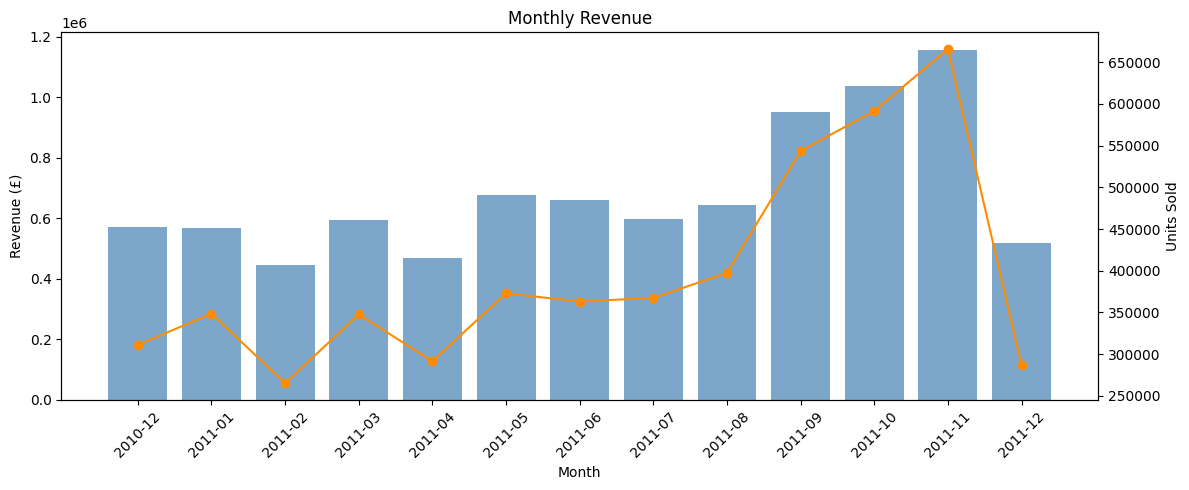

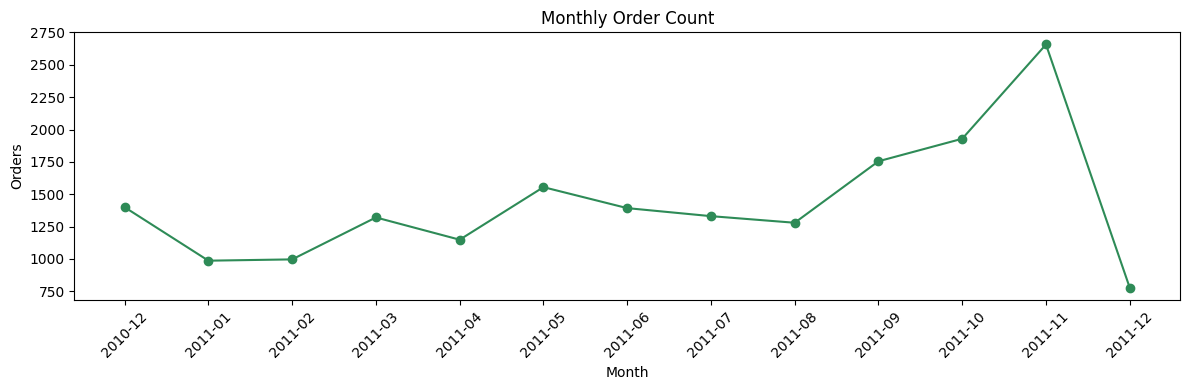

In [16]:
# --- Sales & revenue over time (monthly) ---
data["YearMonth"] = data["InvoiceDate"].dt.to_period("M")

monthly = (
    data.groupby("YearMonth", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
)
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

print("Monthly summary:")
display(monthly)

# Plot revenue and units sold trends
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(monthly["YearMonth"], monthly["Revenue"], color="steelblue", alpha=0.7, label="Revenue")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (£)")
ax1.set_title("Monthly Revenue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly["YearMonth"], monthly["Units_Sold"], color="darkorange", marker="o", label="Units Sold")
ax2.set_ylabel("Units Sold")

fig.tight_layout()
plt.show()

# Order count trend
plt.figure(figsize=(12, 4))
plt.plot(monthly["YearMonth"], monthly["Orders"], marker="o", color="seagreen")
plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue, units sold, and orders by country:


,Country,Revenue,Units_Sold,Orders,Revenue_Pct,Orders_Pct
35,United Kingdom,7285024.644,4241305,16646,81.97,89.82
23,Netherlands,285446.340,200361,94,3.21,0.51
10,EIRE,265262.460,140133,260,2.98,1.40
14,Germany,228678.400,119154,457,2.57,2.47
13,France,208934.310,111428,389,2.35,2.10
0,Australia,138453.810,83891,57,1.56,0.31
30,Spain,61558.560,27933,90,0.69,0.49
32,Switzerland,56443.950,30082,51,0.64,0.28
3,Belgium,41196.340,23237,98,0.46,0.53
31,Sweden,38367.830,36078,36,0.43,0.19


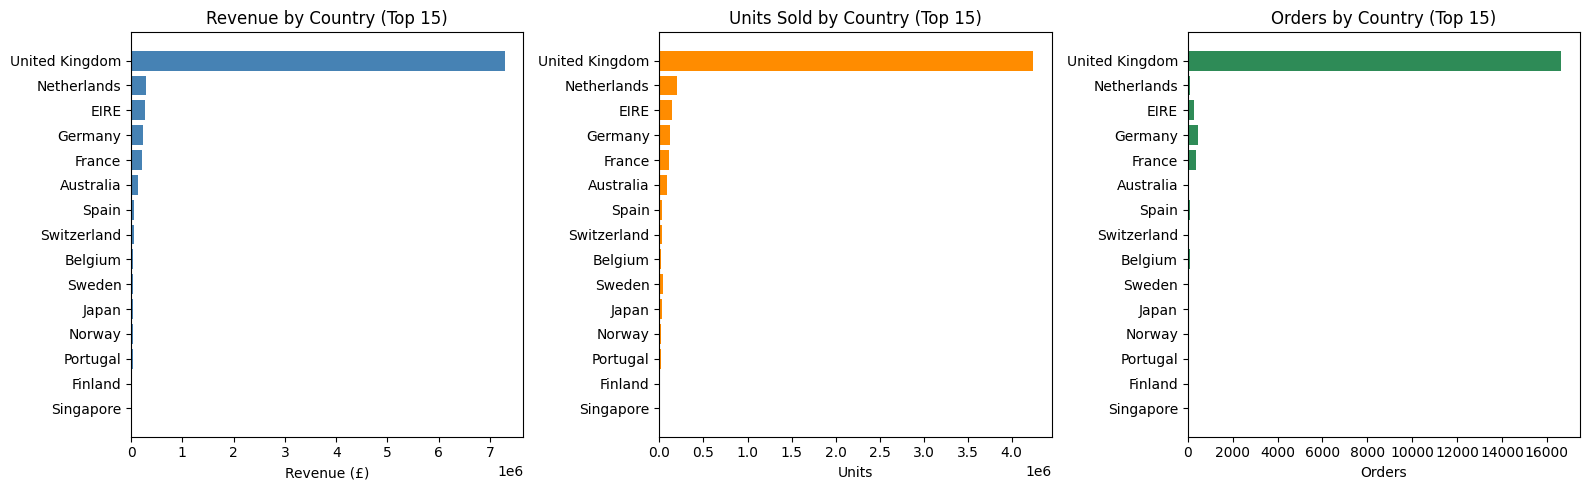

In [17]:
# --- Geographic distribution by country ---
geo = (
    data.groupby("Country", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .sort_values("Revenue", ascending=False)
)

# Share of total for context
geo["Revenue_Pct"] = (geo["Revenue"] / geo["Revenue"].sum() * 100).round(2)
geo["Orders_Pct"] = (geo["Orders"] / geo["Orders"].sum() * 100).round(2)

print("Revenue, units sold, and orders by country:")
display(geo)

# Top 15 countries by revenue
top_geo = geo.head(15)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].barh(top_geo["Country"][::-1], top_geo["Revenue"][::-1], color="steelblue")
axes[0].set_title("Revenue by Country (Top 15)")
axes[0].set_xlabel("Revenue (£)")

axes[1].barh(top_geo["Country"][::-1], top_geo["Units_Sold"][::-1], color="darkorange")
axes[1].set_title("Units Sold by Country (Top 15)")
axes[1].set_xlabel("Units")

axes[2].barh(top_geo["Country"][::-1], top_geo["Orders"][::-1], color="seagreen")
axes[2].set_title("Orders by Country (Top 15)")
axes[2].set_xlabel("Orders")

plt.tight_layout()
plt.show()

Top 20 products by revenue:


,StockCode,Description,Revenue,Units_Sold,Orders
2529,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1245,22423,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703
3576,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
3569,85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600
2027,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
3896,POST,POSTAGE,77803.96,3120,1099
2607,47566,PARTY BUNTING,68785.23,15279,1379
2810,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
3894,M,Manual,53419.93,6933,253
1933,23084,RABBIT NIGHT LIGHT,51251.24,27153,801



Top 20 products by units sold:


,StockCode,Description,Revenue,Units_Sold,Orders
2529,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2027,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
2705,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13558.41,54319,472
3569,85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600
3576,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
2810,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
359,21212,PACK OF 72 RETROSPOT CAKE CASES,16381.88,33670,1029
1035,22197,POPCORN HOLDER,23417.51,30919,632
1933,23084,RABBIT NIGHT LIGHT,51251.24,27153,801
1310,22492,MINI PAINT SET VINTAGE,16039.24,26076,325


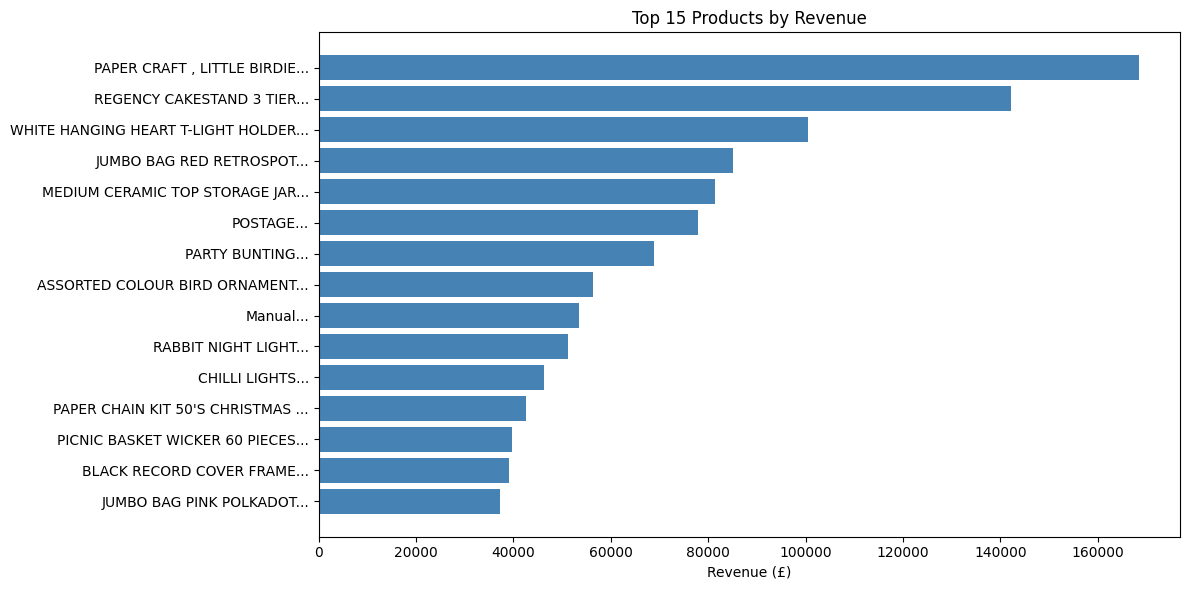

In [19]:
# --- Top performing products ---
top_products = (
    data.groupby(["StockCode", "Description"], as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
    )
    .sort_values("Revenue", ascending=False)
)

print("Top 20 products by revenue:")
display(top_products.head(20))

print("\nTop 20 products by units sold:")
display(top_products.sort_values("Units_Sold", ascending=False).head(20))

# Bar chart — top 15 by revenue
top15 = top_products.head(15)
labels = top15["Description"].str[:35] + "..."

plt.figure(figsize=(12, 6))
plt.barh(labels[::-1], top15["Revenue"][::-1], color="steelblue")
plt.xlabel("Revenue (£)")
plt.title("Top 15 Products by Revenue")
plt.tight_layout()
plt.show()

Total orders: 18,532
Total revenue: £8,887,208.89
Average order value (mean): £479.56
Median order value: £302.57

Monthly AOV:


,YearMonth,AOV
0,2010-12,407.444807
1,2011-01,575.583901
2,2011-02,447.427202
3,2011-03,449.721241
4,2011-04,407.636493
5,2011-05,435.598167
6,2011-06,473.830617
7,2011-07,450.009693
8,2011-08,503.164875
9,2011-09,541.703819


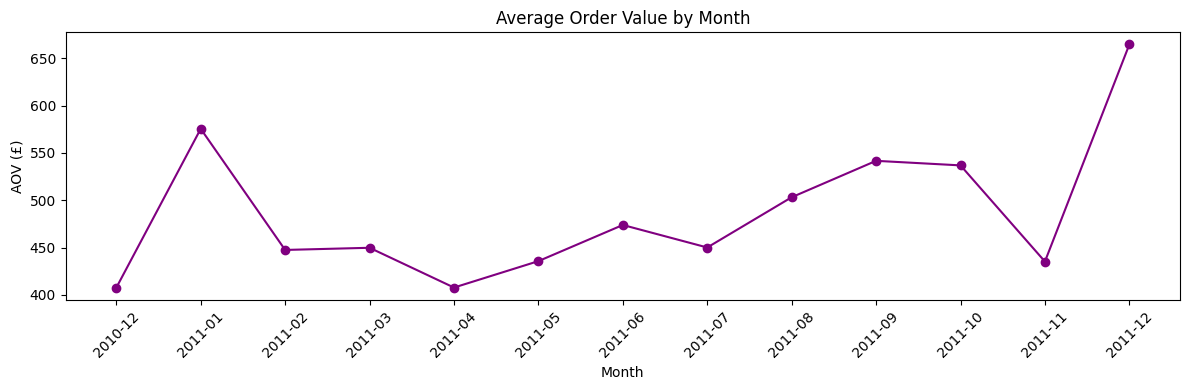

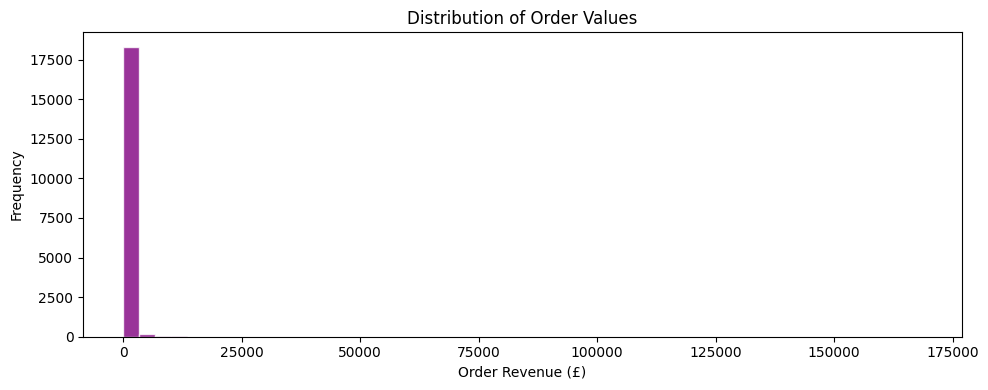

In [20]:
# --- Average order value (AOV) ---
# Order-level totals: one row per invoice
orders = (
    data.groupby("InvoiceNo", as_index=False)
    .agg(
        Order_Revenue=("Revenue", "sum"),
        Items=("Quantity", "sum"),
        Lines=("StockCode", "count"),
    )
)

overall_aov = orders["Order_Revenue"].mean()
median_order_value = orders["Order_Revenue"].median()
total_orders = len(orders)
total_revenue = orders["Order_Revenue"].sum()

print(f"Total orders: {total_orders:,}")
print(f"Total revenue: £{total_revenue:,.2f}")
print(f"Average order value (mean): £{overall_aov:.2f}")
print(f"Median order value: £{median_order_value:.2f}")

# Monthly AOV trend
orders_with_date = data.groupby("InvoiceNo").agg(
    Order_Revenue=("Revenue", "sum"),
    InvoiceDate=("InvoiceDate", "min"),
)
orders_with_date["YearMonth"] = orders_with_date["InvoiceDate"].dt.to_period("M")

monthly_aov = (
    orders_with_date.groupby("YearMonth")["Order_Revenue"]
    .mean()
    .reset_index(name="AOV")
)
monthly_aov["YearMonth"] = monthly_aov["YearMonth"].astype(str)

print("\nMonthly AOV:")
display(monthly_aov)

plt.figure(figsize=(12, 4))
plt.plot(monthly_aov["YearMonth"], monthly_aov["AOV"], marker="o", color="purple")
plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("AOV (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution of order values
plt.figure(figsize=(10, 4))
plt.hist(orders["Order_Revenue"], bins=50, color="purple", edgecolor="white", alpha=0.8)
plt.title("Distribution of Order Values")
plt.xlabel("Order Revenue (£)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Product Category Revenue
*Categories are derived from product `Description` keywords (dataset has no category field).*

In [21]:
import re

def assign_category(description):
    """Map product description to a category using keyword rules (first match wins)."""
    d = str(description).upper()

    if re.search(r"POSTAGE|^POST$|MANUAL|BANK CHARGES|DOTCOM", d):
        return "Fees & Admin"
    if re.search(r"CHRISTMAS|XMAS|SNOWMAN|SANTA|ADVENT", d):
        return "Seasonal & Christmas"
    if re.search(r"BAG|SHOPPER", d) and not re.search(r"PAPER", d[:25]):
        return "Bags & Carriers"
    if re.search(r"LIGHT|CANDLE|T-LIGHT|NIGHT LIGHT|LAMP|CHILLI", d):
        return "Lighting & Candles"
    if re.search(
        r"CAKE|TIN|JAM|KITCHEN|MUG|LUNCH|PLATE|CUP|FOOD|BAKING|PANTRY|TEAPOT|CUTLERY|TEA SET|BOWL",
        d,
    ):
        return "Kitchen, Cake & Dining"
    if re.search(r"NECKLACE|BRACELET|RING|EARRING|JEWEL|BROOCH", d):
        return "Jewelry & Accessories"
    if re.search(
        r"CARD|WRAP|GIFT TAG|STATIONERY|PAPER CHAIN|PAPER CRAFT|NOTEBOOK|PEN |PAINT SET|RIBBON",
        d,
    ):
        return "Cards, Paper & Crafts"
    if re.search(r"GARDEN|PLANT|GNOME|PARASOL", d):
        return "Garden & Outdoor"
    if re.search(r"PARTY|BUNTING|BALLOON|FLAG|BUNNY|TOY|GAME|POPCORN", d):
        return "Party & Novelty"
    if re.search(
        r"DOORMAT|ORNAMENT|FRAME|CLOCK|WICKER|BOARD|CUSHION|VASE|DECORATION|HANGING|METAL SIGN|COAT RACK|SIGN",
        d,
    ):
        return "Home Decor"
    if re.search(r"BOX|STORAGE|JAR|BASKET|DRAWER", d):
        return "Storage & Organisation"
    if re.search(r"HOT WATER BOTTLE|HAND WARMER", d):
        return "Comfort & Homeware"
    if re.search(r"SOAP|BATH|COSMETIC|CREAM|TOWEL", d):
        return "Bath & Body"
    if re.search(r"CLOTH|SCARF|APRON|TEXTILE|FELT|WOOL|FAN", d):
        return "Textiles & Fabric"
    return "Other"


# Assign category on cleaned data
data_cat = df_clean.copy()
data_cat["Category"] = data_cat["Description"].apply(assign_category)

In [22]:
# Revenue, units, and SKU count by category
category_summary = (
    data_cat.groupby("Category", as_index=False)
    .agg(
        Revenue=("Revenue", "sum"),
        Units_Sold=("Quantity", "sum"),
        Orders=("InvoiceNo", "nunique"),
        SKUs=("StockCode", "nunique"),
    )
    .sort_values("Revenue", ascending=False)
)

total_rev = category_summary["Revenue"].sum()
category_summary["Revenue_Pct"] = (category_summary["Revenue"] / total_rev * 100).round(2)
category_summary["Cumulative_Pct"] = category_summary["Revenue_Pct"].cumsum().round(2)

print(f"Total revenue: £{total_rev:,.2f}\n")
display(category_summary)

# Categories that drive most revenue (Pareto: ~80% threshold)
top_categories = category_summary[category_summary["Cumulative_Pct"] <= 80].copy()
if len(top_categories) < len(category_summary):
    # Include the category that pushes cumulative share over 80%
    next_row = category_summary.iloc[len(top_categories)]
    top_categories = pd.concat([top_categories, next_row.to_frame().T], ignore_index=True)

print("Categories contributing to ~80% of revenue:")
display(top_categories[["Category", "Revenue", "Revenue_Pct", "Cumulative_Pct"]])

Total revenue: £8,887,208.89



,Category,Revenue,Units_Sold,Orders,SKUs,Revenue_Pct,Cumulative_Pct
8,"Kitchen, Cake & Dining",1900039.260,933795,13633,496,21.38,21.38
10,Other,1486355.690,1024074,14296,1157,16.72,38.10
6,Home Decor,1425831.413,638556,12229,404,16.04,54.14
0,Bags & Carriers,875808.120,530351,8365,169,9.85,63.99
9,Lighting & Candles,686718.700,412115,9278,302,7.73,71.72
13,Storage & Organisation,520143.710,305243,7868,155,5.85,77.57
2,"Cards, Paper & Crafts",517451.400,521006,7765,214,5.82,83.39
12,Seasonal & Christmas,389038.320,288317,4742,150,4.38,87.77
3,Comfort & Homeware,208210.100,56267,2980,27,2.34,90.11
5,Garden & Outdoor,181091.820,61034,4332,92,2.04,92.15


Categories contributing to ~80% of revenue:


,Category,Revenue,Revenue_Pct,Cumulative_Pct
0,"Kitchen, Cake & Dining",1900039.26,21.38,21.38
1,Other,1486355.69,16.72,38.1
2,Home Decor,1425831.413,16.04,54.14
3,Bags & Carriers,875808.12,9.85,63.99
4,Lighting & Candles,686718.7,7.73,71.72
5,Storage & Organisation,520143.71,5.85,77.57
6,"Cards, Paper & Crafts",517451.4,5.82,83.39


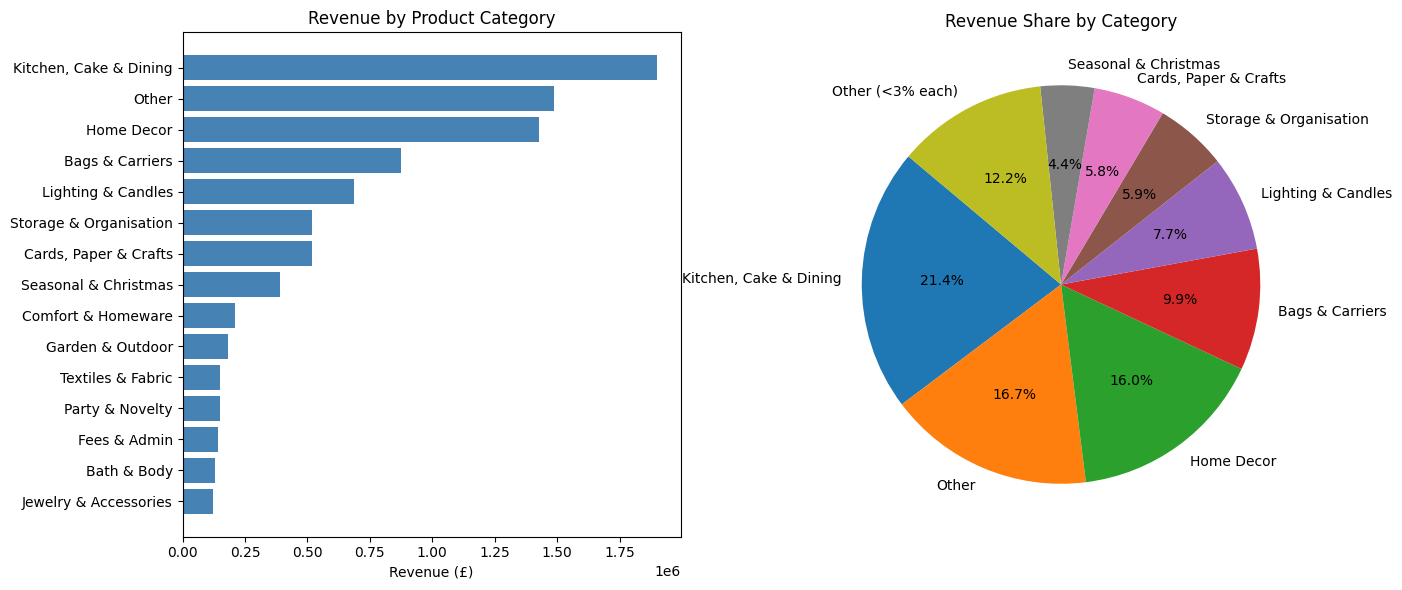

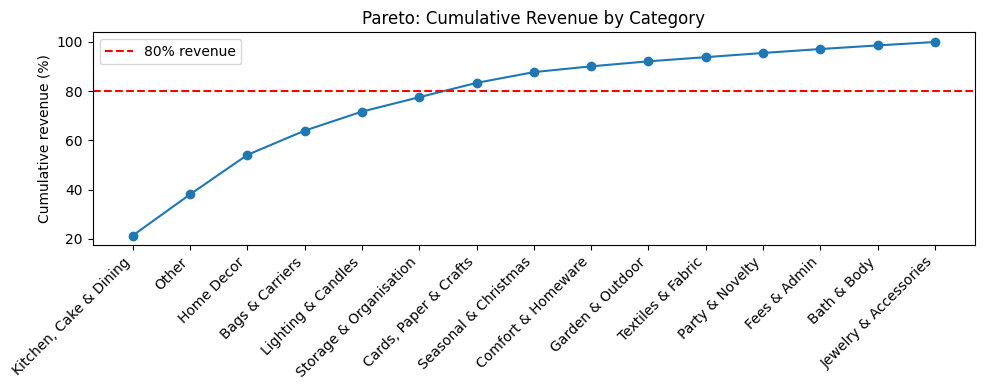

In [23]:
# Visual: revenue share by category
plot_df = category_summary.sort_values("Revenue", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Horizontal bar — revenue by category
axes[0].barh(plot_df["Category"], plot_df["Revenue"], color="steelblue")
axes[0].set_xlabel("Revenue (£)")
axes[0].set_title("Revenue by Product Category")

# Pie — top categories + Other grouped for readability
pie_df = category_summary.copy()
small = pie_df[pie_df["Revenue_Pct"] < 3]
if len(small) > 0:
    other_rev = small["Revenue"].sum()
    pie_df = pie_df[pie_df["Revenue_Pct"] >= 3]
    pie_df = pd.concat(
        [pie_df, pd.DataFrame([{"Category": "Other (<3% each)", "Revenue": other_rev}])],
        ignore_index=True,
    )
axes[1].pie(pie_df["Revenue"], labels=pie_df["Category"], autopct="%1.1f%%", startangle=140)
axes[1].set_title("Revenue Share by Category")

plt.tight_layout()
plt.show()

# Cumulative revenue curve (categories ranked)
cat_sorted = category_summary.sort_values("Revenue", ascending=False)
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cat_sorted) + 1), cat_sorted["Cumulative_Pct"], marker="o")
plt.axhline(80, color="red", linestyle="--", label="80% revenue")
plt.xticks(range(1, len(cat_sorted) + 1), cat_sorted["Category"], rotation=45, ha="right")
plt.ylabel("Cumulative revenue (%)")
plt.title("Pareto: Cumulative Revenue by Category")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Top products within the highest-revenue categories
top_n = 5
leading = category_summary.head(4)["Category"].tolist()

for cat in leading:
    print(f"\n--- Top {top_n} SKUs in: {cat} ---")
    subset = (
        data_cat[data_cat["Category"] == cat]
        .groupby(["StockCode", "Description"], as_index=False)["Revenue"]
        .sum()
        .sort_values("Revenue", ascending=False)
        .head(top_n)
    )
    display(subset)

# Unclassified products still in "Other" (review mapping if this share is high)
other_share = category_summary.loc[
    category_summary["Category"] == "Other", "Revenue_Pct"
].values
if len(other_share):
    print(f"\n'Other' category share: {other_share[0]:.2f}% of revenue")
    print("Top unclassified products by revenue:")
    display(
        data_cat[data_cat["Category"] == "Other"]
        .groupby(["StockCode", "Description"], as_index=False)["Revenue"]
        .sum()
        .sort_values("Revenue", ascending=False)
        .head(10)
    )


--- Top 5 SKUs in: Kitchen, Cake & Dining ---


,StockCode,Description,Revenue
183,22423,REGENCY CAKESTAND 3 TIER,142264.75
433,47566,PARTY BUNTING,68785.23
366,23298,SPOTTY BUNTING,35509.55
231,22720,SET OF 3 CAKE TINS PANTRY DESIGN,33298.30
276,22960,JAM MAKING SET WITH JARS,32616.22



--- Top 5 SKUs in: Other ---


,StockCode,Description,Revenue
315,21754,HOME BUILDING BLOCK WORD,15504.51
541,22847,BREAD BIN DINER STYLE IVORY,13131.89
64,20750,RED RETROSPOT MINI CASES,12208.85
392,22171,3 HOOK PHOTO SHELF ANTIQUE WHITE,12160.08
63,20749,ASSORTED COLOUR MINI CASES,12107.51



--- Top 5 SKUs in: Home Decor ---


,StockCode,Description,Revenue
335,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
147,22502,PICNIC BASKET WICKER 60 PIECES,39619.50
22,21137,BLACK RECORD COVER FRAME,39045.80
245,23284,DOORMAT KEEP CALM AND COME IN,35880.85
312,82484,WOOD BLACK BOARD ANT WHITE FINISH,34414.71



--- Top 5 SKUs in: Bags & Carriers ---


,StockCode,Description,Revenue
166,85099B,JUMBO BAG RED RETROSPOT,85040.54
83,22386,JUMBO BAG PINK POLKADOT,37254.36
168,85099F,JUMBO BAG STRAWBERRY,30569.32
9,20725,LUNCH BAG RED RETROSPOT,27868.80
97,23199,JUMBO BAG APPLES,26426.30



'Other' category share: 16.72% of revenue
Top unclassified products by revenue:


,StockCode,Description,Revenue
315,21754,HOME BUILDING BLOCK WORD,15504.51
541,22847,BREAD BIN DINER STYLE IVORY,13131.89
64,20750,RED RETROSPOT MINI CASES,12208.85
392,22171,3 HOOK PHOTO SHELF ANTIQUE WHITE,12160.08
63,20749,ASSORTED COLOUR MINI CASES,12107.51
623,23077,DOUGHNUT LIP GLOSS,11615.70
316,21755,LOVE BUILDING BLOCK WORD,11398.71
873,82486,WOOD S/3 CABINET ANT WHITE FINISH,11343.20
1157,85014B,RED RETROSPOT UMBRELLA,10217.72
347,21891,TRADITIONAL WOODEN SKIPPING ROPE,9998.32
